In [45]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from src.ps_dare.paths import solve_path

PREDICTIONS_DIR = "data/weekly/predictions"
PREDICTIONS_FILE_ILI = f"{PREDICTIONS_DIR}/ili_giustiniani_20260909_212028.csv"
PREDICTIONS_FILE_HW = f"{PREDICTIONS_DIR}/ili_pediatrico_20260909_212028.csv"

standardised_plot = False

df_ili = pd.read_csv(solve_path(PREDICTIONS_FILE_ILI))
df_hw = pd.read_csv(solve_path(PREDICTIONS_FILE_HW))

date_columns = ["date", "date_start_training", "date_end_training", "date_end_testing"]
for frame in (df_ili, df_hw):
    frame[date_columns] = frame[date_columns].apply(pd.to_datetime)

In [46]:
ili_drivers = [
    "humidex",
    "frost",
    "indoor_wet_bulb",
]
hw_drivers = [
    "none",
    "hu",
    "summer_days",
]
all_drivers = [driver for driver in ili_drivers + hw_drivers if driver != "none"]

driver_colors = {
    "none": "tab:green",
    "humidex": "tab:blue",
    "frost": "tab:orange",
    "indoor_wet_bulb": "tab:purple",
    "hu": "tab:red",
    "summer_days": "tab:brown",
}
driver_labels = {
    "none": "No driver",
    "humidex": "Humidex",
    "frost": "Frost",
    "indoor_wet_bulb": "Indoor wet bulb",
    "hu": "HU",
    "summer_days": "Summer days",
}

available_drivers = sorted(
    (set(df_ili["drivers_used"]) | set(df_hw["drivers_used"])) - {"none"}
)
missing_drivers = sorted(set(all_drivers) - set(available_drivers))
if missing_drivers:
    raise ValueError(f"Drivers missing from the prediction files: {missing_drivers}")

print(f"Total available drivers: {len(available_drivers)}")
print(f"ILI prediction drivers: {ili_drivers}")
print(f"HW prediction drivers: {hw_drivers}")

Total available drivers: 18
ILI prediction drivers: ['humidex', 'frost', 'indoor_wet_bulb']
HW prediction drivers: ['none', 'hu', 'summer_days']


In [47]:
pd.DataFrame(
    {"Driver": available_drivers},
    index=pd.RangeIndex(1, len(available_drivers) + 1, name="#"),
)

,Driver
#,
1,CO_mean
2,CO_peak
3,NO2_mean
4,NO2_peak
5,SO2_mean
6,SO2_peak
7,abs_hu
8,frost
9,heating_degree_days


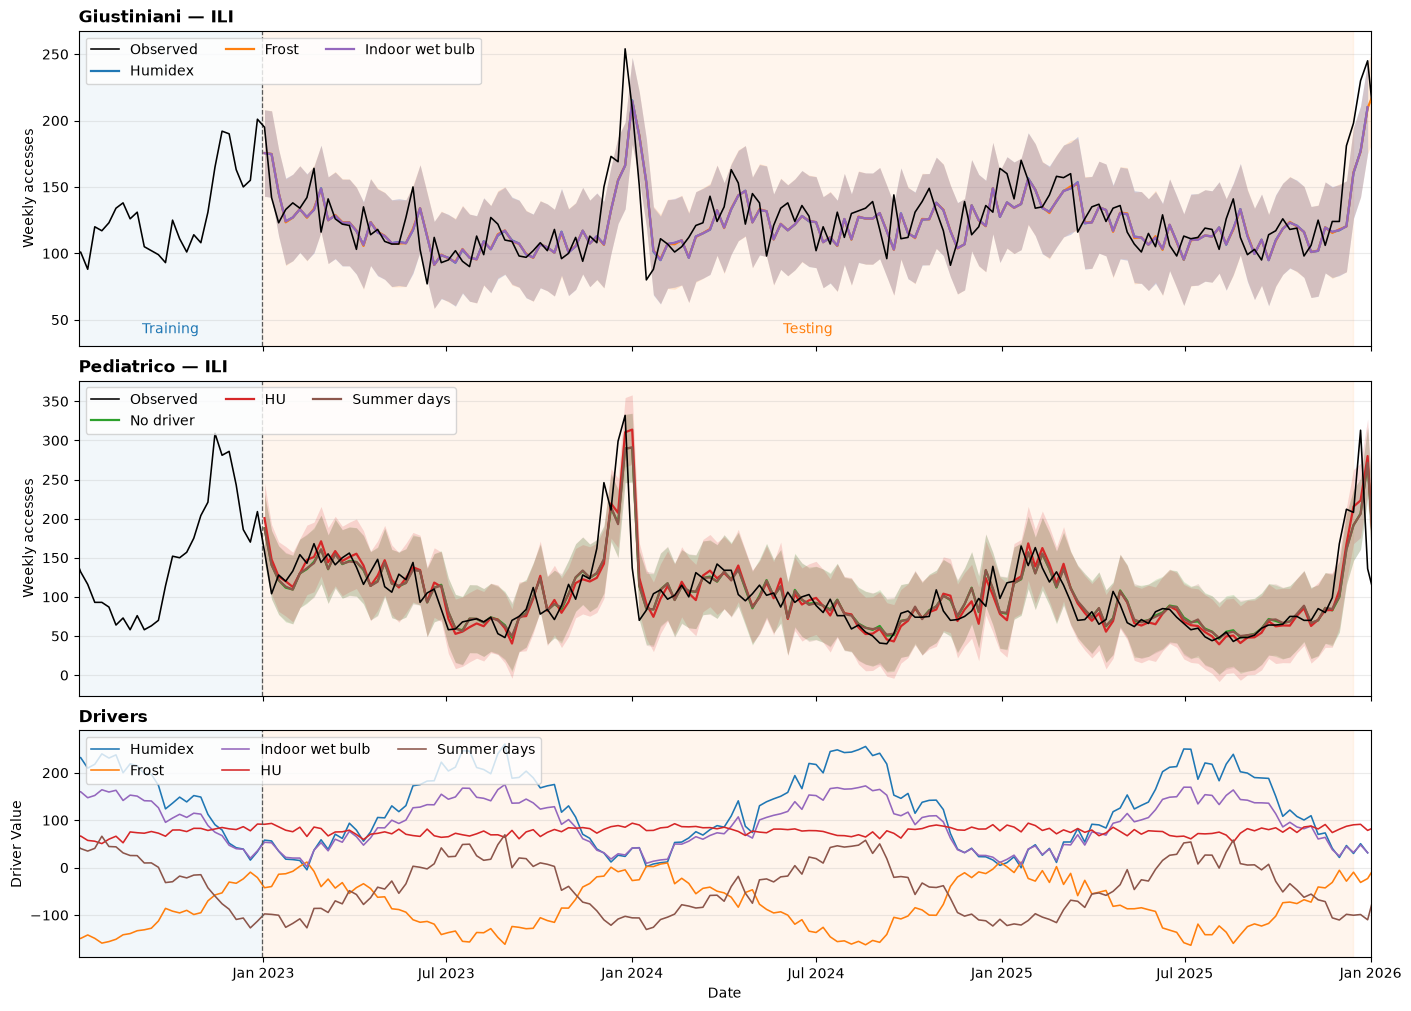

In [48]:
def model_rows(frame, driver):
    rows = frame.loc[frame["drivers_used"].eq(driver)].sort_values("date")
    if rows.empty:
        raise ValueError(f"No prediction found for {driver!r}")
    return rows


def plot_outcome(ax, frame, drivers, title):
    # Observations are identical across models; the no-driver run has the full test span.
    observed = model_rows(frame, "none")
    observed = observed.loc[observed["phase"].isin(["training", "testing"])]
    ax.plot(
        observed["date"], observed["n_accesses"], color="black",
        linewidth=1.15, label="Observed", zorder=4,
    )

    for driver in drivers:
        forecast = model_rows(frame, driver)
        forecast = forecast.loc[forecast["phase"].eq("testing")].dropna(
            subset=["prediction", "prediction_lower_bound", "prediction_upper_bound"]
        )
        color = driver_colors[driver]
        label = driver_labels[driver]
        ax.plot(
            forecast["date"], forecast["prediction"], color=color,
            linewidth=1.6, label=label, zorder=3,
        )
        ax.fill_between(
            forecast["date"], forecast["prediction_lower_bound"],
            forecast["prediction_upper_bound"], color=color, alpha=0.16,
            linewidth=0, zorder=2,
        )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("Weekly accesses")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", ncols=3)


training_start = df_ili["date_start_training"].iloc[0]
training_end = df_ili["date_end_training"].iloc[0]
testing_start = min(
    frame.loc[frame["phase"].eq("testing"), "date"].min()
    for frame in (df_ili, df_hw)
)
zoom_start = testing_start - pd.DateOffset(months=6)
testing_end = max(
    model_rows(df_ili, driver).loc[lambda x: x["phase"].eq("testing"), "date"].max()
    for driver in ili_drivers
)
testing_end = max(
    testing_end,
    *(model_rows(df_hw, driver).loc[lambda x: x["phase"].eq("testing"), "date"].max()
      for driver in hw_drivers),
)
testing_end = min(testing_end, pd.Timestamp("2025-12-15"))

fig, axes = plt.subplots(
    3, 1, figsize=(14, 10), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 0.72]}, constrained_layout=True,
)

plot_outcome(axes[0], df_ili, ili_drivers, "Giustiniani — ILI")
plot_outcome(axes[1], df_hw, hw_drivers, "Pediatrico — ILI")

# Standardisation lets drivers with different units share one readable panel.
for driver in all_drivers:
    values = model_rows(df_ili, driver)
    values = values.loc[values["phase"].isin(["training", "testing"]), ["date", "driver_value"]]
    values = values.dropna(subset=["driver_value"])
    standardised = (values["driver_value"] - values["driver_value"].mean()) / values["driver_value"].std()
    if standardised_plot:
        driver_to_plot=standardised
    else:
        driver_to_plot=values["driver_value"]
    axes[2].plot(
        values["date"], driver_to_plot, color=driver_colors[driver],
        linewidth=1.15, label=driver_labels[driver],
    )

axes[2].set_title("Drivers", loc="left", fontweight="bold")
axes[2].set_ylabel("Standardised value" if standardised_plot else "Driver Value")
axes[2].set_xlabel("Date")
axes[2].grid(axis="y", alpha=0.25)
axes[2].legend(loc="upper left", ncols=3)

for ax in axes:
    ax.axvspan(training_start, training_end, color="tab:blue", alpha=0.055, zorder=0)
    ax.axvspan(training_end, testing_end, color="tab:orange", alpha=0.07, zorder=0)
    ax.axvline(training_end, color="0.35", linestyle="--", linewidth=0.9)
    # Keep a short training lead-in and devote most horizontal space to testing.
    ax.set_xlim(zoom_start, testing_end)

axes[0].text(
    zoom_start + (training_end - zoom_start) / 2, 0.03, "Training",
    transform=axes[0].get_xaxis_transform(), ha="center", va="bottom", color="tab:blue",
)
axes[0].text(
    training_end + (testing_end - training_end) / 2, 0.03, "Testing",
    transform=axes[0].get_xaxis_transform(), ha="center", va="bottom", color="tab:orange",
)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xlim(zoom_start, pd.to_datetime("2026-01-01"))
plt.show()